# Install Triton and verify installation

In [9]:
# Select GPU T4 x 2 accelator and install triton
!pip install triton

In [10]:
# Verify installation
import torch
import triton
import triton.language as tl 

# Check if Triton can access the GPU
print(f"Triton version: {triton.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Simple test: define a JIT kernel
@triton.jit
def dummy_kernel(x_ptr):
    return

print("Triton JIT check: Success")

Triton version: 3.5.0
GPU Available: True
GPU Name: Tesla T4
Triton JIT check: Success


In [11]:
# Set cache directory
import os
os.environ["TRITON_CACHE_DIR"] = "/kaggle/working/triton_cache"

# Set device
current_device_id = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{current_device_id}")

# 1D Convolution

$$y[h,w] = \sum_{k=0}^{K-1} x\left[h,\; w + k - \left\lfloor \frac{K}{2} \right\rfloor \right] \cdot \mathrm{weight}[k]$$

### Kernel and Wrapper

In [12]:
@triton.jit
def conv_1d_kernel(
    # Pointers to input
    x_ptr, weight_ptr, output_ptr,
    # Input dimensions
    H, W, K,
    # Strides
    stride_xh, stride_xw,
    stride_oh, stride_ow,
    # Meta-parameters
    BLOCK_SIZE_H: tl.constexpr,
    BLOCK_SIZE_W: tl.constexpr,
):
    # Tile output and launch one program for each tile in output. Map program id to tile coordinates
    # Tile order in column-major index ordering
    pid = tl.program_id(axis=0) # Index of tile in column-major index ordering
    num_pid_h = tl.cdiv(H, BLOCK_SIZE_H) # Number of tiles (programs) along H dimension in output
    pid_h = pid % num_pid_h # Row index of tile (program) in output (along H)
    pid_w = pid // num_pid_h # Column index of tile (program) in output (along W)

    # Compute tile offsets
    offsets_h = pid_h * BLOCK_SIZE_H + tl.arange(0, BLOCK_SIZE_H)
    offsets_w = pid_w * BLOCK_SIZE_W + tl.arange(0, BLOCK_SIZE_W)

    # Centring shift
    half_k = K // 2

    accumulator = tl.zeros((BLOCK_SIZE_H, BLOCK_SIZE_W), dtype=tl.float32)

    for k in range(K):
        """
        k = 0
        Tile: [p0 p1 p2 p3]
        W w0: [w0 w0 w0 w0]
        -------------------
        k = 1
        Tile: [p1 p2 p3 p4] (shifted)
        W w1: [w1 w1 w1 w1]
        """
        curr_window = offsets_w + k - half_k # Shift window left by half the filter width

        # Verify current window >= 0 and current window < W
        mask = (
            (offsets_h[:, None] < H) &
            (curr_window[None, :] >= 0) &
            (curr_window[None, :] < W) 
        )

        # Load x tile
        x = tl.load(x_ptr + offsets_h[:, None] * stride_xh + curr_window[None, :] * stride_xw,
                    mask=mask, other=0.0)

        # Load weight
        w = tl.load(weight_ptr + k)

        # Multiply and accumulate
        accumulator += x * w

    output_mask = (offsets_h[:, None] < H) & (offsets_w[None, :] < W)
    tl.store(output_ptr + offsets_h[:, None] * stride_oh + offsets_w[None, :] * stride_ow, 
             value=accumulator, mask=output_mask)
        

def conv_1d(x, weight, BLOCK_SIZE_H=32, BLOCK_SIZE_W=32):
    # Input dimens
    H, W = x.shape
    K = weight.shape[0]
    
    # Allocate output
    output = torch.empty_like(x)

    # Define launch grid: 1D grid that represents total number of tilles
    grid = lambda meta: (
        triton.cdiv(H, meta["BLOCK_SIZE_H"]) * triton.cdiv(W, meta["BLOCK_SIZE_W"]),
    )

    # Call kernel
    conv_1d_kernel[grid](
        # Pointers to inputs
        x, weight, output,
        # Input dimensions
        H, W, K,
        # Strides
        x.stride(0), x.stride(1),
        output.stride(0), output.stride(1),
        # Meta-parameters
        BLOCK_SIZE_H=BLOCK_SIZE_H,
        BLOCK_SIZE_W=BLOCK_SIZE_W,
    )

    return output

### Test and Benchmark Helpers

In [13]:
def test_conv_1d_kernel(size: tuple, weight_size: int, atol=1e-6, rtol=1e-5, device=DEVICE):
    torch.manual_seed(42)
    assert isinstance(size, tuple) and len(size) == 2

    H, W = size
    K = weight_size
    half_k = K // 2

    x = torch.randn(H, W, device=device)
    weight = torch.randn(K, device=device)

    # Triton output
    output_triton = conv_1d(x, weight)

    # PyTorch output
    x_4d = x.unsqueeze(0).unsqueeze(0)
    weight_4d = weight.view(1, 1, 1, K)

    # Pad PyTorch input symmetrically (left, right, top, bottom)
    x_padded = torch.nn.functional.pad(x_4d, (half_k, half_k, 0, 0), mode="constant", value=0)

    output_ref = torch.nn.functional.conv2d(x_padded, weight_4d).squeeze()
    
    torch.testing.assert_close(output_triton, output_ref, atol=atol, rtol=rtol)
    print("Passed")


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["K"],
        x_vals=[i for i in range(1, 50, 2)], # Odd filter widths
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "Torch"],
        styles=[("blue", "-"), ("red", "-")],
        ylabel="GB/s",
        plot_name="conv-1d-performance",
        args={"H": 2048, "W": 4096},
    )
)
def benchmark(H, W, K, provider):
    torch.manual_seed(42)

    x = torch.randn((H, W), device=DEVICE, dtype=torch.float32)
    weight = torch.randn((K,), device=DEVICE, dtype=torch.float32)

    quantiles = [0.15, 0.5, 0.85]

    if provider == "torch":
        half_k = K // 2
        x_4d = x.unsqueeze(0).unsqueeze(0) # [1, 1, H, W]
        weight_4d = weight.view(1, 1, 1, K) # [1, 1, 1, K]
        x_padded = torch.nn.functional.pad(x_4d, (half_k, half_k, 0, 0), mode="constant", value=0)
        min_ms, ms, max_ms = triton.testing.do_bench(
            lambda: torch.nn.functional.conv2d(
                x_padded,
                weight_4d,
            ).squeeze(),
            quantiles=quantiles,
        )
    elif provider == "triton":
        min_ms, ms, max_ms = triton.testing.do_bench(
            lambda: conv_1d(x, weight),
            quantiles=quantiles,
        )

    # Approximate bytes moved: read x + read weight + write output
    bytes_moved = (
        x.numel() * x.element_size()
        + weight.numel() * weight.element_size()
        + x.numel() * x.element_size()
    )
    
    gbps = lambda ms: bytes_moved * 1e-9 / (ms * 1e-3)
    return gbps(min_ms), gbps(ms), gbps(max_ms)

## Test

In [14]:
test_conv_1d_kernel((1024, 1024), 5)
test_conv_1d_kernel((2048, 4096), 11)

Passed
Passed


## Benchmark

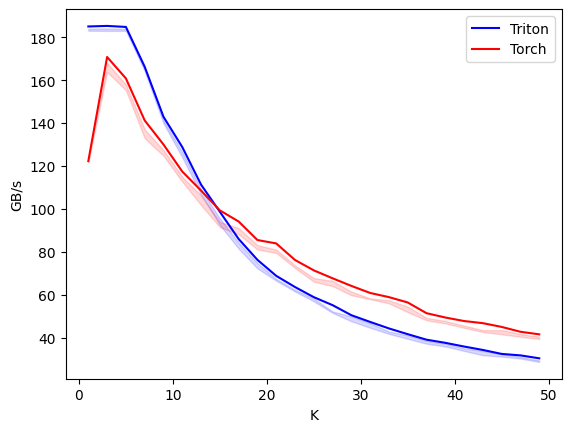

conv-1d-performance:
       K      Triton       Torch
0    1.0  185.022151  122.316448
1    3.0  185.281263  170.794572
2    5.0  184.810240  160.825818
3    7.0  166.252677  141.241435
4    9.0  142.945482  130.031817
5   11.0  128.852597  117.441527
6   13.0  111.333091  108.566305
7   15.0   98.698885   99.335861
8   17.0   86.016802   94.162917
9   19.0   76.298445   85.522041
10  21.0   68.840424   83.946289
11  23.0   63.627269   76.243541
12  25.0   58.915475   71.396405
13  27.0   55.185685   67.701060
14  29.0   50.505089   64.156450
15  31.0   47.366593   60.868727
16  33.0   44.341090   58.923360
17  35.0   41.660959   56.436995
18  37.0   39.095859   51.443326
19  39.0   37.630325   49.430353
20  41.0   35.901557   47.785382
21  43.0   34.312130   46.791703
22  45.0   32.463164   45.047851
23  47.0   31.783497   42.783249
24  49.0   30.415747   41.584043


In [15]:
benchmark.run(print_data=True, show_plots=True)

# Scratch

In [16]:
# [0*w0  x0*w0  x1*w0  x2*w0]
# [      x0*w1  x1*w1  x2*w1  x3*w1]
# [             x1*w2  x2*w2  x3*w2  x4*w2]